In [1]:
#!pip install shap

In [2]:
import pickle
import pandas as pd
import shap
import matplotlib.pyplot as plt
import numpy as np

C:\Users\jmugu\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load model and configs
with open('heloc_random_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('model_config.pkl', 'rb') as f:
    config = pickle.load(f)

with open('preprocessing_info.pkl', 'rb') as f:
    prep_info = pickle.load(f)


# Applicant Data 
raw_data = {
    'ExternalRiskEstimate': 65,
    'MSinceOldestTradeOpen': 150,
    'MSinceMostRecentTradeOpen': 8,
    'AverageMInFile': 75,
    'NumSatisfactoryTrades': 18,
    'NumTrades60Ever2DerogPubRec': 1,
    'NumTrades90Ever2DerogPubRec': 0,
    'PercentTradesNeverDelq': 92,
    'MSinceMostRecentDelq': -9,  # Missing - will be handled
    'MaxDelq2PublicRecLast12M': 6,
    'MaxDelqEver': 6,
    'NumTotalTrades': 20,
    'NumTradesOpeninLast12M': 2,
    'PercentInstallTrades': 35,
    'MSinceMostRecentInqexcl7days': 1,
    'NumInqLast6M': 2,
    'NumInqLast6Mexcl7days': 2,
    'NetFractionRevolvingBurden': -9,  # Missing - will be handled
    'NetFractionInstallBurden': 45,
    'NumRevolvingTradesWBalance': 5,
    'NumInstallTradesWBalance': 2,
    'NumBank2NatlTradesWHighUtilization': 1,
    'PercentTradesWBalance': 70
}

# Preprocess data
df_new = pd.DataFrame([raw_data])

# Replace missing codes (-9, -8, -7) with median
for col in df_new.columns:
    if col in prep_info['median_values']:
        df_new.loc[df_new[col].isin(prep_info['missing_codes']), col] = prep_info['median_values'][col]

# Drop features not used in model
df_new = df_new.drop(columns=prep_info['dropped_features'], errors='ignore')

# Ensure correct order (CRITICAL!)
df_new = df_new[prep_info['feature_order']]

# Make Predictions
probability = model.predict_proba(df_new)[:, 1][0]

if probability >= config['threshold']:
    print(f"❌ DENY - {probability:.1%} default risk (threshold: {config['threshold']})")
else:
    print(f"✅ APPROVE - {probability:.1%} default risk (send to loan officer)")

FileNotFoundError: [Errno 2] No such file or directory: 'heloc_random_forest_model.pkl'


Your Default Risk: 66.4%
Denial Threshold: 55%
Decision: DENIED (risk exceeds threshold)

📋 TOP 5 REASONS FOR DENIAL:
------------------------------------------------------------
1. 🔴 MSinceOldestTradeOpen: 150.0
   → This increased predicted default likelihood by 9.9 points
2. 🔴 NumInqLast6Mexcl7days: 2.0
   → This increased predicted default likelihood by 2.8 points
3. 🔴 NumInstallTradesWBalance: 2.0
   → This increased predicted default likelihood by 1.7 points
4. 🔴 NumTradesOpeninLast12M: 2.0
   → This increased predicted default likelihood by 1.1 points
5. 🔴 AverageMInFile: 75.0
   → This increased predicted default likelihood by 1.1 points

📊 VISUAL BREAKDOWN:


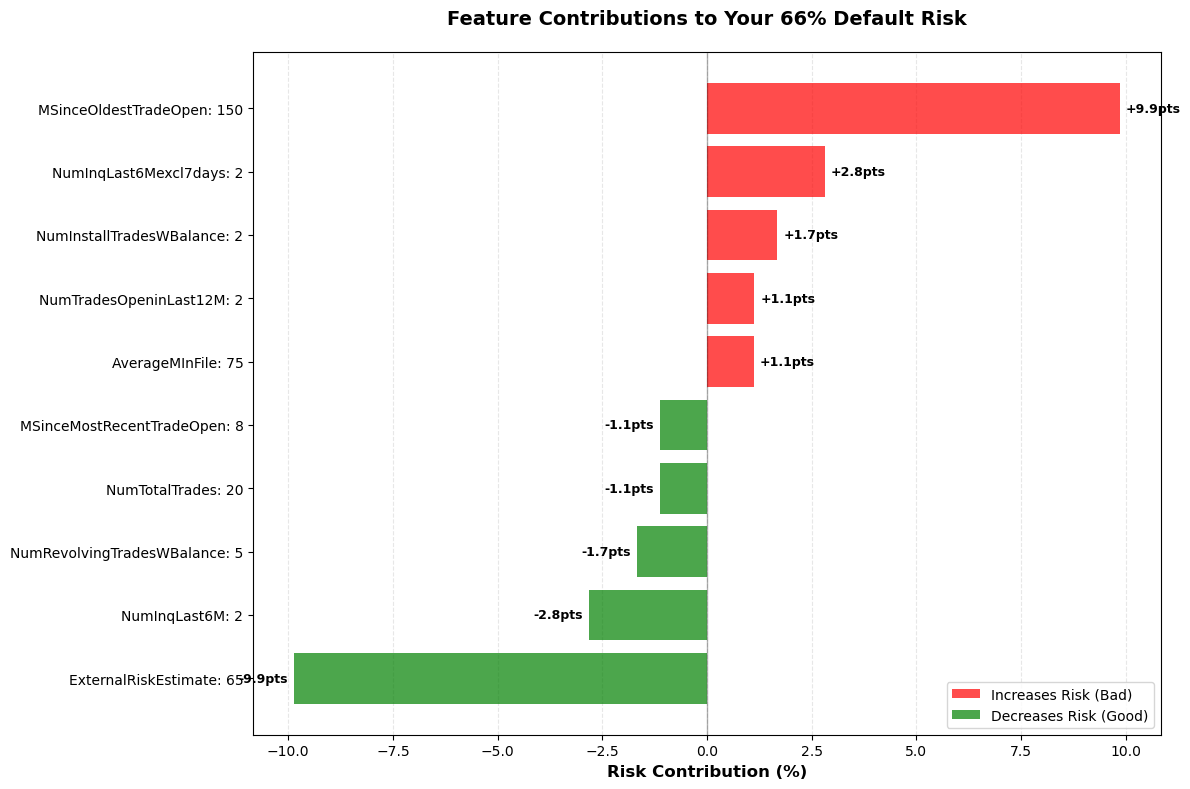

In [ ]:
# Only run explanation if applicant was denied
if probability >= config['threshold']:
    
    # Compute SHAP values for this applicant
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(df_new)
    
    # Get SHAP values for Bad class
    if isinstance(shap_values, list):
        shap_values_bad = shap_values[1][0]
    else:
        shap_values_bad = shap_values[0][:22]
    
    # Ensure 1D arrays
    shap_values_bad = np.array(shap_values_bad).flatten()[:22]
    applicant_values = np.array(df_new.iloc[0].values).flatten()
    feature_names = np.array(prep_info['feature_order'])
    
    # Create explanation dataframe
    explanation_df = pd.DataFrame({
        'Feature': feature_names,
        'Your_Value': applicant_values,
        'SHAP_Impact': shap_values_bad
    }).sort_values('SHAP_Impact', ascending=False) #key=abs, ascending=False)  # Sort by absolute impact
    
    explanation_all_df = pd.DataFrame({
        'Feature': feature_names,
        'Your_Value': applicant_values,
        'SHAP_Impact': shap_values_bad
    }).sort_values('SHAP_Impact', key=abs, ascending=False)

    # TEXT EXPLANATION - TOP 5 FACTORS
    print(f"\nYour Default Risk: {probability:.1%}")
    print(f"Denial Threshold: {config['threshold']:.0%}")
    print(f"Decision: DENIED (risk exceeds threshold)\n")
    
    print("📋 TOP 5 REASONS FOR DENIAL:")
    print("-"*60)
    
    top_5 = explanation_df.head(5)
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        impact_pct = row['SHAP_Impact'] * 100
        if row['SHAP_Impact'] > 0:
            symbol = "🔴"
            impact_text = f"increased predicted default likelihood by {abs(impact_pct):.1f} points"
        else:
            symbol = "🟢"
            impact_text = f"decreased predicted default likelihood by {abs(impact_pct):.1f} points"
        
        print(f"{i}. {symbol} {row['Feature']}: {row['Your_Value']:.1f}")
        print(f"   → This {impact_text}")
    
    # IMPROVED VISUAL - HORIZONTAL BAR CHART
    print("\n📊 VISUAL BREAKDOWN:")
    
    # Take top 10 most impactful features
    top_10 = pd.concat([top_5, explanation_all_df], ignore_index = True).drop_duplicates().head(10).copy()
    
    # Convert to percentages
    top_10['Impact_Pct'] = top_10['SHAP_Impact'] * 100
    
    # Create labels with feature name and value
    top_10['Label'] = top_10.apply(
        lambda row: f"{row['Feature']}: {row['Your_Value']:.0f}", 
        axis=1
    )
    
    # Sort by impact for display
    top_10 = top_10.sort_values('Impact_Pct', ascending=True)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Color bars: red for positive (bad), green for negative (good)
    colors = ['red' if x > 0 else 'green' for x in top_10['Impact_Pct']]
    
    # Horizontal bar chart
    bars = ax.barh(range(len(top_10)), top_10['Impact_Pct'], color=colors, alpha=0.7)
    
    # Labels
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['Label'], fontsize=10)
    ax.set_xlabel('Risk Contribution (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Feature Contributions to Your {probability:.0%} Default Risk', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Add vertical line at 0
    ax.axvline(x=0, color='black', linewidth=1, linestyle='-', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_10['Impact_Pct'])):
        if abs(val) > 1:  # Only show label if impact > 1%
            label_x = val + (0.15 if val > 0 else -0.15)
            ax.text(label_x, i, f'{val:+.1f}pts', 
                   va='center', ha='left' if val > 0 else 'right',
                   fontsize=9, fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.7, label='Increases Risk (Bad)'),
        Patch(facecolor='green', alpha=0.7, label='Decreases Risk (Good)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

else:
    print("\n✅ Application approved - no explanation needed!")

STOP HERE

---

EXPLANATION FOR DENIAL
Features: 22
Values: 22
SHAP: 22

TOP 5 REASONS FOR DENIAL:
------------------------------------------------------------
1. MSinceOldestTradeOpen: 150.0
   → This increased predicted probability of default by 9.855 points
2. NumInqLast6Mexcl7days: 2.0
   → This increased predicted probability of default by 2.809 points
3. NumInstallTradesWBalance: 2.0
   → This increased predicted probability of default by 1.678 points
4. NumTradesOpeninLast12M: 2.0
   → This increased predicted probability of default by 1.128 points
5. AverageMInFile: 75.0
   → This increased predicted probability of default by 1.114 points

VISUAL BREAKDOWN:


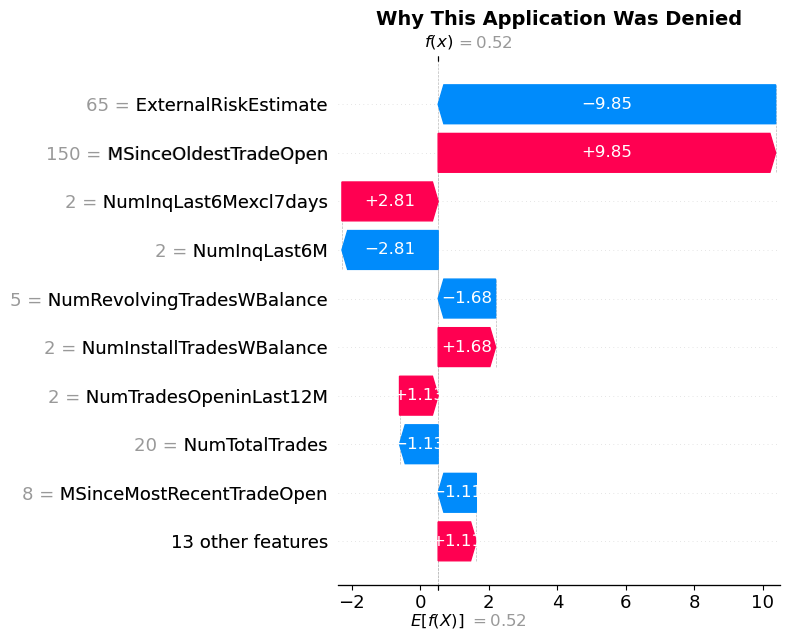

In [ ]:
# Only run explanation if applicant was denied
if probability >= config['threshold']:
    print("EXPLANATION FOR DENIAL")
    
    # Compute SHAP values for this applicant
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(df_new)*100
    
    # SHAP returns values for both classes [Good, Bad]
    # We want Bad class (index 1)
    if isinstance(shap_values, list):
        # shap_values is [Good_values, Bad_values]
        # Each is shape (1, 22) for 1 applicant, 22 features
        shap_values_bad = shap_values[1][0]  # Bad class, first applicant
    else:
        # Single output - take first 22 values (Bad class)
        shap_values_bad = shap_values[0][:22]
    
    # Ensure 1D arrays
    shap_values_bad = np.array(shap_values_bad).flatten()[:22]  # Only first 22
    applicant_values = np.array(df_new.iloc[0].values).flatten()
    feature_names = np.array(prep_info['feature_order'])
    
    # Debug: Check lengths
    print(f"Features: {len(feature_names)}")
    print(f"Values: {len(applicant_values)}")
    print(f"SHAP: {len(shap_values_bad)}")
    
    # Create explanation dataframe
    explanation_df = pd.DataFrame({
        'Feature': feature_names,
        'Your_Value': applicant_values,
        'SHAP_Impact': shap_values_bad
    }).sort_values('SHAP_Impact', ascending=False)
    
    print("\nTOP 5 REASONS FOR DENIAL:")
    print("-"*60)
    
    top_5 = explanation_df.head(5)
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        impact_text = "increased" if row['SHAP_Impact'] > 0 else "decreased"
        print(f"{i}. {row['Feature']}: {row['Your_Value']:.1f}")
        print(f"   → This {impact_text} predicted probability of default by {abs(row['SHAP_Impact']):.3f} points")
    
    print("\nVISUAL BREAKDOWN:")
    plt.figure(figsize=(10, 6))
    
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_bad,
            base_values=base_val,
            data=applicant_values,
            feature_names=feature_names.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title('Why This Application Was Denied', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)

else:
    print("\n✅ Application approved - no explanation needed!")